# Initialize

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import random

In [ ]:
# Default directory
dir = r'C:\Non-system\Course Material\M1A\STA2453\data'

In [ ]:
master_table = pd.read_excel(dir+r"\MasterTable_AI_FlowCAM.xlsx", 0)
Huron_overlap_csv = pd.concat([
    pd.read_csv(d) # subset it here so that it's not that large
    for d in glob.glob(os.path.join(dir+r'/HURONOverlap_csv', '*'))
])
Simc_overlap_csv = pd.concat([
    pd.read_csv(d) # subset it here so that it's not that large
    for d in glob.glob(os.path.join(dir+r'/SIMCOverlap_csv', '*'))
])
Huron_overlap_csv['Lake'] = 'Huron'
Simc_overlap_csv['Lake'] = 'Simcoe'
print(Huron_overlap_csv.size)
print(Simc_overlap_csv.size)

106219377
75614258


In [ ]:
# class labels that we are interested in:
zooplanktons_interested = ['Calanoid_1', 'Cyclopoid_1', 'Bosmina_1', 'Herpacticoida',
                           'Chironomid', 'Chydoridae', 'Daphnia']
Simc_overlap_csv['Class_interest'] = Simc_overlap_csv['Class'].apply(
    lambda c: c if c in zooplanktons_interested else 'others'
)
Huron_overlap_csv['Class_interest'] = Huron_overlap_csv['Class'].apply(
    lambda c: c if c in zooplanktons_interested else 'others'
)

In [ ]:
# categorize columns into different types:
col_Huron_only = list(set(Huron_overlap_csv.columns) - set(Simc_overlap_csv.columns))
# parameters related to the shape. Likely to be irrelevant when taking image as input
col_shape_related = ['Area..ABD.', 'Area..Filled.', 'Aspect.Ratio', 'Capture.X', 'Capture.Y',
                     'Circle.Fit', 'Circularity', 'Circularity..Hu.', 'Compactness', 'Convex.Perimeter',
                     'Convexity', 'Diameter..ABD.', 'Diameter..ESD.', 'Diameter..FD.', 'Edge.Gradient',
                     'Elongation', 'Feret.Angle.Max', 'Feret.Angle.Min', 'Fiber.Curl', 'Fiber.Straightness',
                     'Geodesic.Aspect.Ratio', 'Geodesic.Length', 'Geodesic.Thickness','Intensity', 'Length',
                     'Particles.Per.Chain', 'Perimeter', 'Roughness', 'Sigma.Intensity',
                     'Sphere.Complement', 'Sphere.Count', 'Sphere.Unknown', 'Sphere.Volume','Sum.Intensity',
                     'Symmetry', 'Transparency','Volume..ABD.', 'Volume..ESD.', 'Width']
# parameters related to devices, time, etc. Should be dropped to prevent overleading
col_irrelevant = ['Camera', 'Date', 'Elapsed.Time','Source.Image', 'Time', 'Timestamp']
# parameters that are relevant and not covered when taking image as parameter. Always kept.
col_relevant = ['Calibration.Factor']
# parameters of biovolume related data - highly missing...
col_biovolume = ['Biovolume..Cylinder.', 'Biovolume..P..Spheroid.', 'Biovolume..Sphere.']
# parameter used to connect the row to an image
col_image_connect = ['Image.File', 'Image.Height', 'Image.Width', 'Image.X', 'Image.Y', 'Source.Image']
# parameters that need more careful processing
col_others = ['Calibration.Image', 'Filter.Score', 'Original.Reference.ID',]
# parameters that are labels
col_labels = ['Class', 'Class_interest', 'Lake']
# parameters with only 1 unique value (thus useless)
col_single_valued = [c for c in col_shape_related+col_relevant if len(Huron_overlap_csv[c].value_counts())<=1]
# parameters we want to use for EDA
col_EDA = list(set(col_shape_related+col_relevant+col_labels) - set(col_Huron_only+col_single_valued))

## Data preprocess

In [ ]:
full_data_Simc = Simc_overlap_csv[col_EDA]
full_data_Huron = Huron_overlap_csv[col_EDA]
full_data = pd.concat([full_data_Simc, full_data_Huron]).reset_index().reindex(sorted(col_EDA), axis=1)

In [ ]:
zooplanktons_Simc = Simc_overlap_csv[Simc_overlap_csv['Class'].isin(zooplanktons_interested)][col_EDA]
zooplanktons_Huron = Huron_overlap_csv[Huron_overlap_csv['Class'].isin(zooplanktons_interested)][col_EDA]
zooplanktons = pd.concat([zooplanktons_Huron, zooplanktons_Simc]).reset_index().reindex(sorted(col_EDA), axis=1)

In [ ]:
print(zooplanktons_Simc.shape)
print(zooplanktons_Huron.shape)
print(zooplanktons.shape)
print(full_data_Simc.shape)
print(full_data_Huron.shape)
print(full_data.shape)

(417317, 37)
(101654, 37)
(518971, 37)
(1239578, 37)
(1051677, 37)
(2291255, 37)


# EDA

## Balancedness

Number of samples for each class

In [ ]:
full_data[full_data['Class_interest']=='others']['Class'].value_counts()

Class
TooSmall          1095461
Floc_1             499237
LargeZ-1           114326
Cyclo_2             20115
CountGT500          16883
CopepodSpp          11091
Bubbles              7925
Nauplii              2652
Unknown              1671
CladoceraSpp         1448
Sididae               543
Floc_2                345
InsectLarvae          165
Eggs                  119
Insecta                98
Holopedidae            86
Naididae               40
Nematode               34
Rotifer                12
Holopididae            12
Cercopagididae          7
Polyphemidae            6
Holopediidae            5
Leptodoridae            2
Trombidiforme           1
Name: count, dtype: int64

Proportion of each zooplankton species among all data that are known to be zooplanktons

In [ ]:
pd.DataFrame(zooplanktons['Class'].value_counts(normalize=True))

,proportion
Class,
Calanoid_1,0.579479
Cyclopoid_1,0.396300
Bosmina_1,0.014895
Chironomid,0.004066
Herpacticoida,0.003742
Daphnia,0.001133
Chydoridae,0.000385


## correlation heatmap

In [ ]:
corr_spearman = zooplanktons.drop(col_labels, axis=1).corr(
    method='spearman'
).dropna(axis=1, how='all').dropna(axis=0, how='all')
corr_kendall = zooplanktons.drop(col_labels, axis=1).corr(
    method='kendall'
).dropna(axis=1, how='all').dropna(axis=0, how='all')

### Heat map using Spearman correlation

<bound method Figure.show of <Figure size 1000x800 with 2 Axes>>

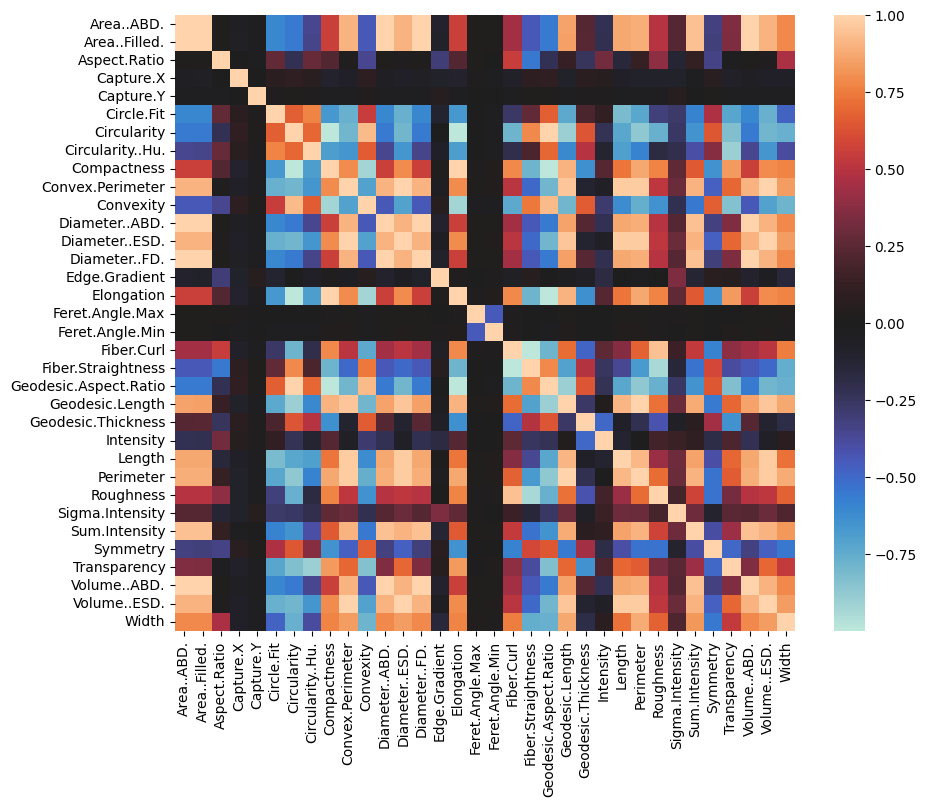

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, xticklabels=1, yticklabels=1, cmap="icefire", ax=ax)
fig.show

### Heatmap using Kendall correlation

<bound method Figure.show of <Figure size 1000x800 with 2 Axes>>

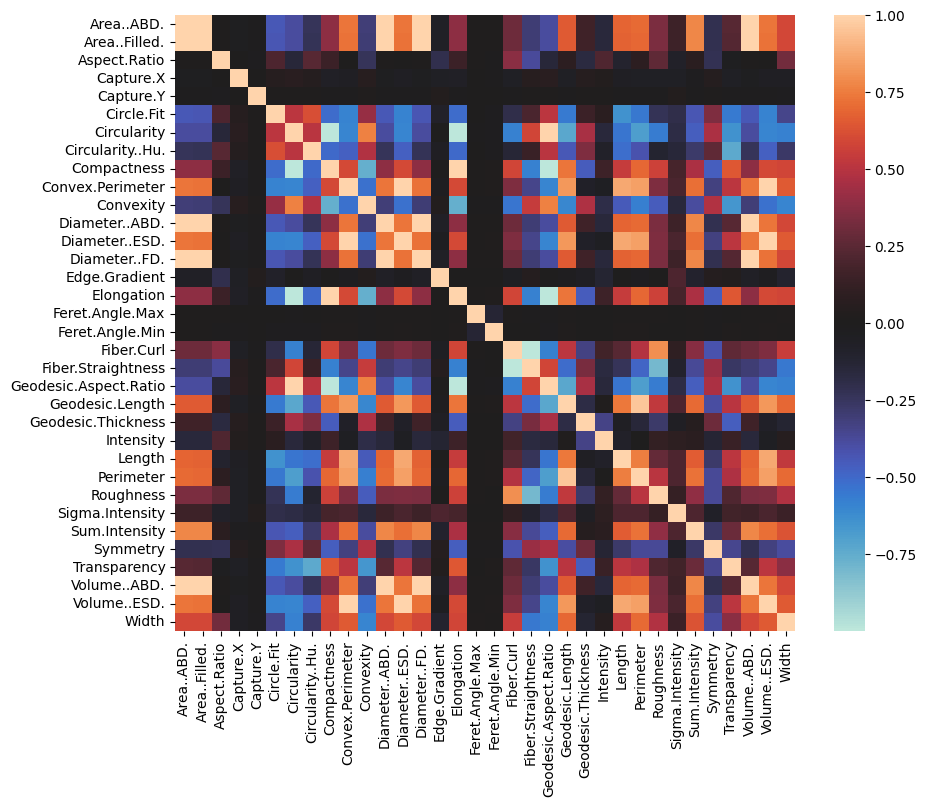

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_kendall, xticklabels=1, yticklabels=1, cmap="icefire", ax=ax)
fig.show

## boxplot by category for each value

<bound method Figure.show of <Figure size 1700x1700 with 35 Axes>>

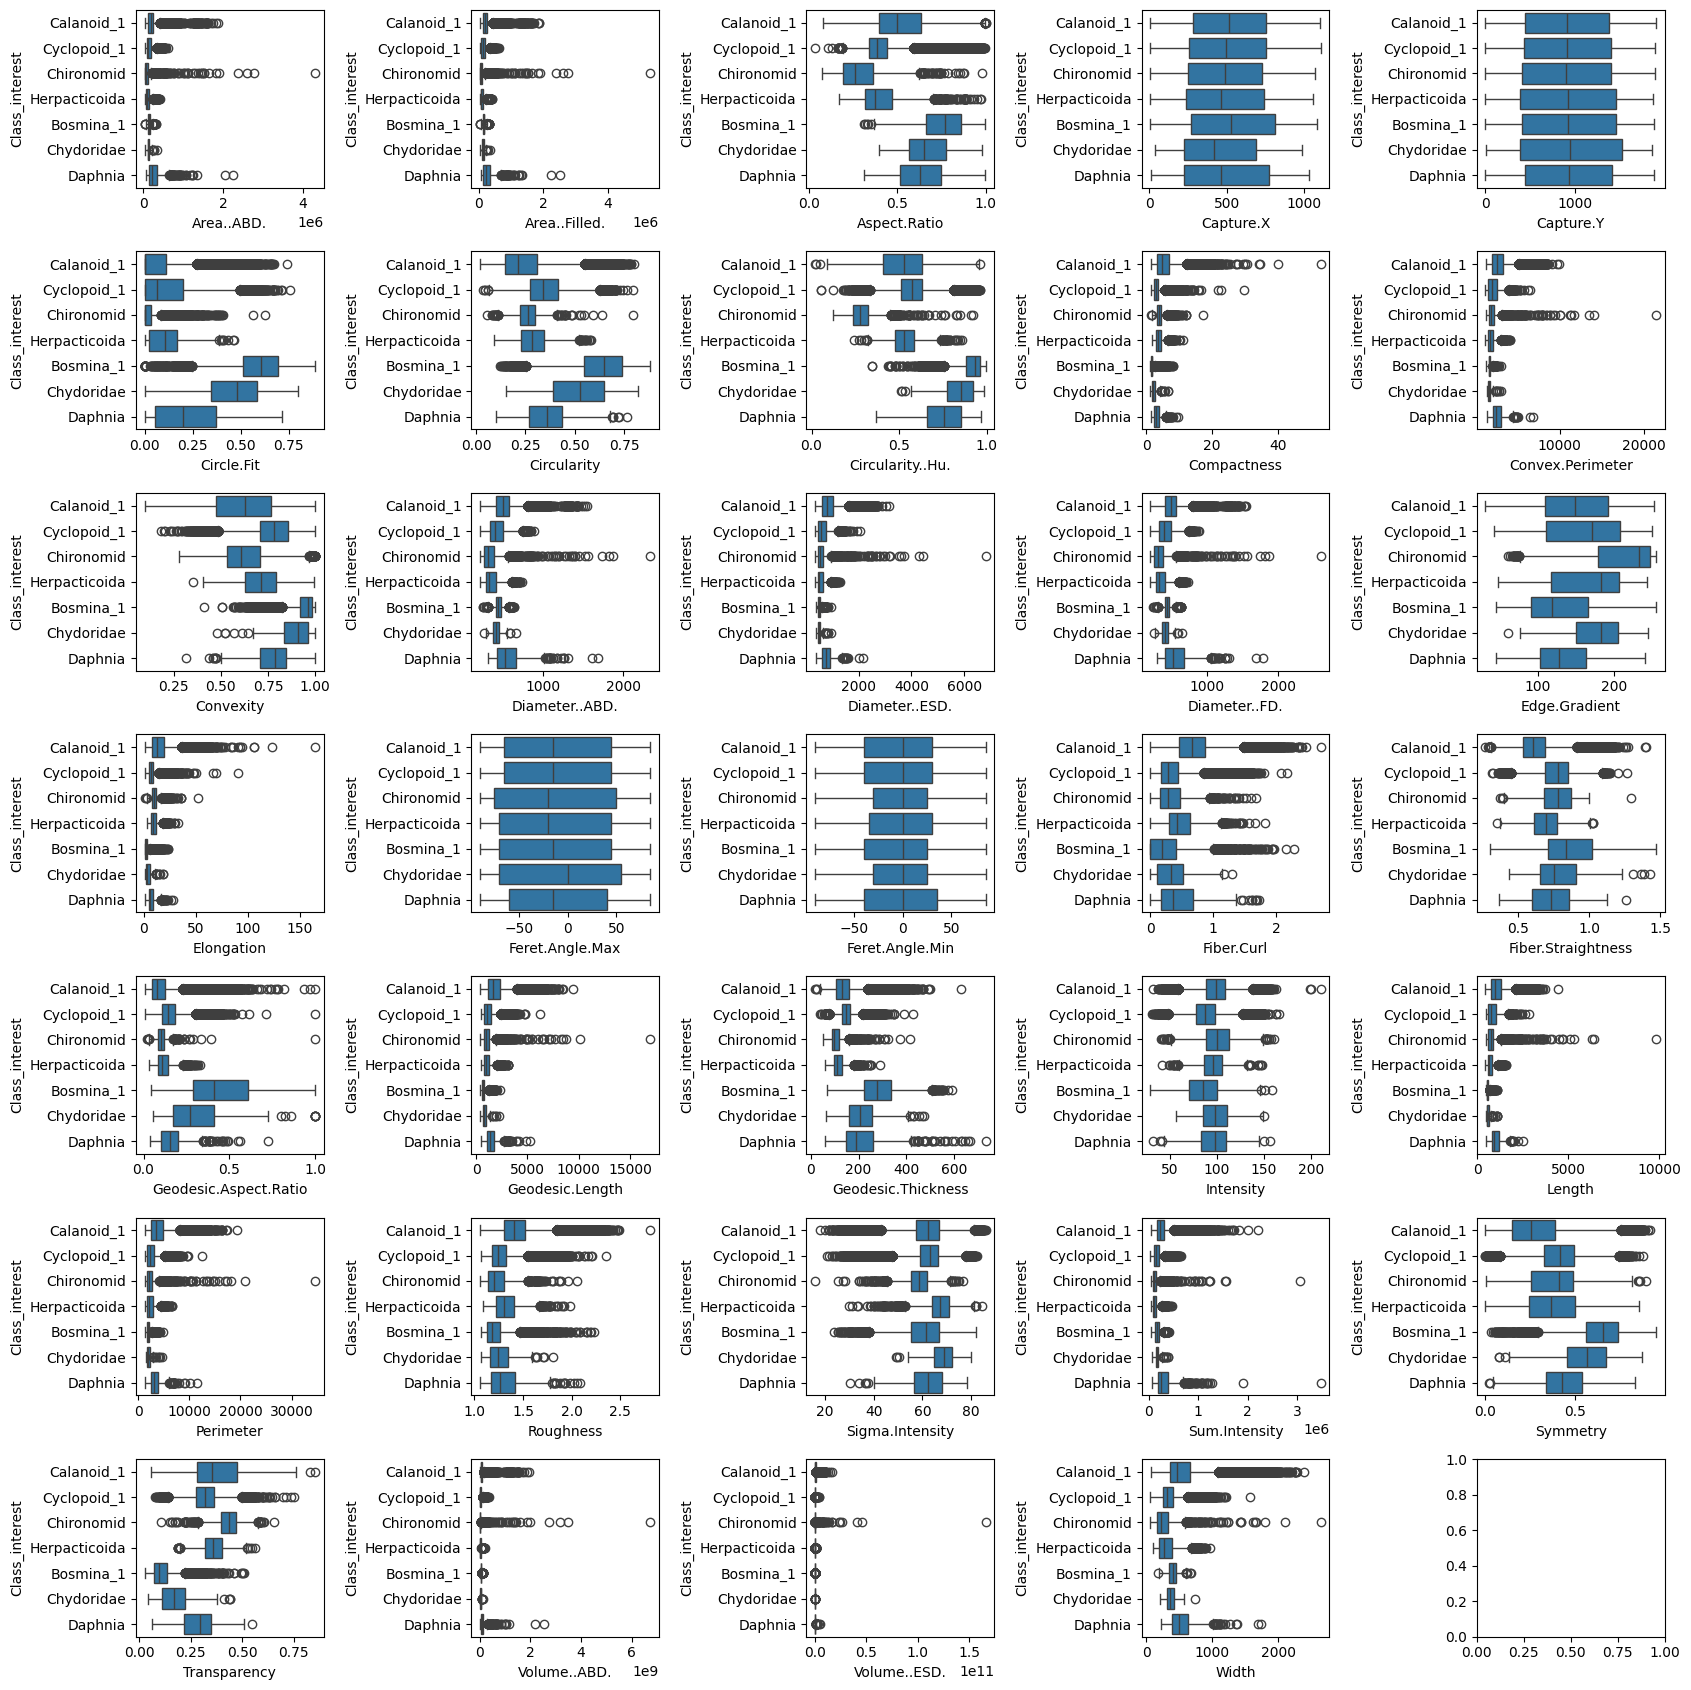

In [ ]:
params = list(set(zooplanktons.columns) - set(col_labels))
params.sort()
fig, ax = plt.subplots(nrows=len(params)//5+1, ncols=5, figsize=(17, 17))

for j in range(len(params)//5+1):
    for i in range(5):
        if j*5+i >= len(params): break
        if params[j*5+i] in col_labels: continue
        sns.boxplot(data=zooplanktons, x=params[j*5+i], y='Class_interest',
                    orient='h', ax=ax[j][i])
plt.tight_layout()
fig.show

## Simple model fitting

Train-test split

In [ ]:
train_test_split = np.array([True] * int(len(zooplanktons)*0.8) + \
                            [False] * (len(zooplanktons) - int(len(zooplanktons)*0.8//1)))
random.shuffle(train_test_split)
train_X = zooplanktons[train_test_split].drop(col_labels, axis=1)
train_y = zooplanktons[train_test_split]['Class']
test_X = zooplanktons[~train_test_split].drop(col_labels, axis=1)
test_y = zooplanktons[~train_test_split]['Class']

### Logistic regression

In [ ]:
# scale the training data
scaler = StandardScaler()
train_X_sc = scaler.fit_transform(train_X)
clf = LogisticRegression(random_state=0, max_iter=500).fit(train_X_sc, train_y)

In [ ]:
print("train accuracy: ")
print(clf.score(train_X_sc, train_y))
print("test accuracy: ")
print(clf.score(scaler.fit_transform(test_X), test_y))

train accuracy: 
0.8807325086228491
test accuracy: 
0.8817187725805674


Now, take a look at test accuracy for each subset

In [ ]:
test_y_hat = clf.predict(scaler.fit_transform(test_X))
test_results = pd.DataFrame({
    'predict': test_y_hat,
    'actual_class':  test_y
})
test_results['correct'] = test_results.apply(
    lambda row: row['predict']==row['actual_class'], axis=1
)
test_results.groupby(by='actual_class', as_index=False)['correct'].mean()

,actual_class,correct
0,Bosmina_1,0.849332
1,Calanoid_1,0.896312
2,Chironomid,0.888412
3,Chydoridae,0.000000
4,Cyclopoid_1,0.872058
5,Daphnia,0.264957
6,Herpacticoida,0.109489


### Decision tree

In [ ]:
# scale the training data
tree = DecisionTreeClassifier(random_state=0, max_depth=12).fit(train_X, train_y)

In [ ]:
print("train accuracy: ")
print(tree.score(train_X, train_y))
print("test accuracy: ")
print(tree.score(test_X, test_y))

train accuracy: 
0.9073115979729078
test accuracy: 
0.8868442603208248


In [ ]:
test_y_hat = tree.predict(test_X)
test_results = pd.DataFrame({
    'predict': test_y_hat,
    'actual_class':  test_y
})
test_results['correct'] = test_results.apply(
    lambda row: row['predict']==row['actual_class'], axis=1
)
test_results.groupby(by='actual_class', as_index=False)['correct'].mean()

,actual_class,correct
0,Bosmina_1,0.830261
1,Calanoid_1,0.911010
2,Chironomid,0.733906
3,Chydoridae,0.043478
4,Cyclopoid_1,0.866837
5,Daphnia,0.179487
6,Herpacticoida,0.048662
